In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
BASE_PATH = "../data/raw"

train = pd.read_csv(f"{BASE_PATH}/train.csv")
stores = pd.read_csv(f"{BASE_PATH}/stores.csv")
oil = pd.read_csv(f"{BASE_PATH}/oil.csv")
holidays = pd.read_csv(f"{BASE_PATH}/holidays_events.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [8]:
sales = train.groupby("date")["sales"].sum()
sales.index = pd.to_datetime(sales.index)

sales.head()

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

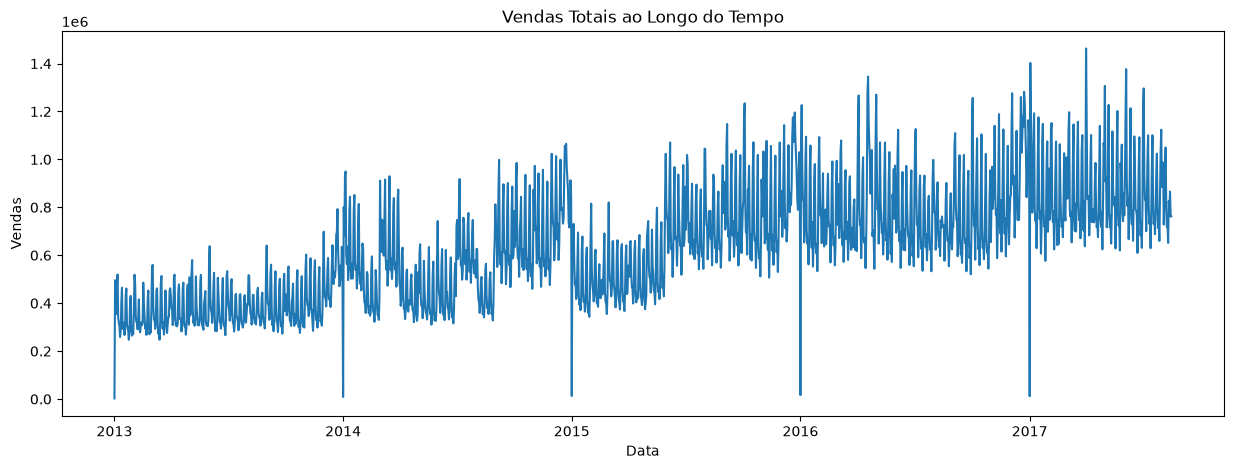

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(sales)
plt.title("Vendas Totais ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

In [10]:
sales.isnull().sum()

np.int64(0)

In [11]:
sales.index.min(), sales.index.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [12]:
sales.index.to_series().diff().value_counts().head()

date
1 days    1679
2 days       4
Name: count, dtype: int64

In [15]:
sales = sales.ffill()

In [16]:
sales.isnull().sum()

np.int64(0)

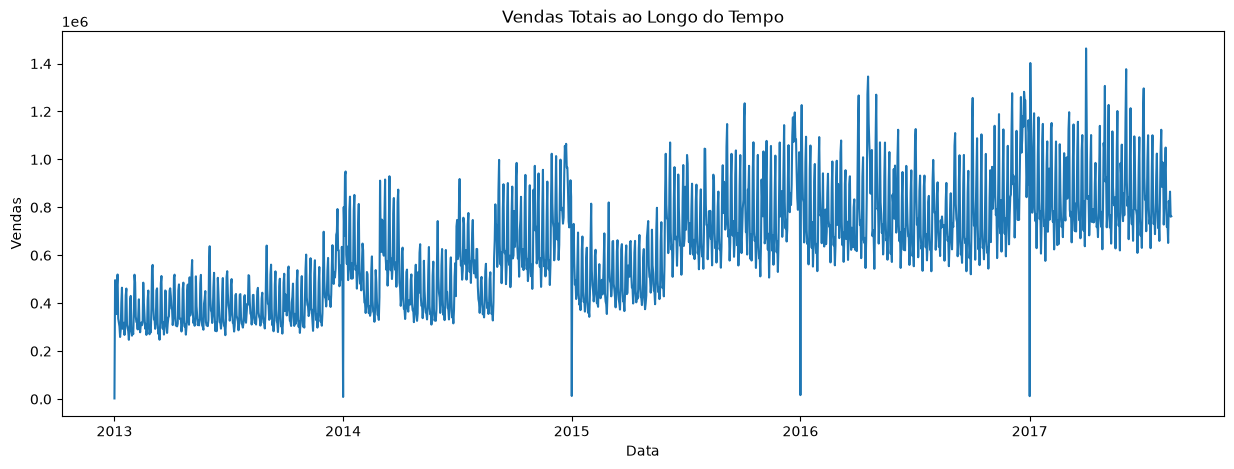

In [17]:
plt.figure(figsize=(15,5))
plt.plot(sales)
plt.title("Vendas Totais ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

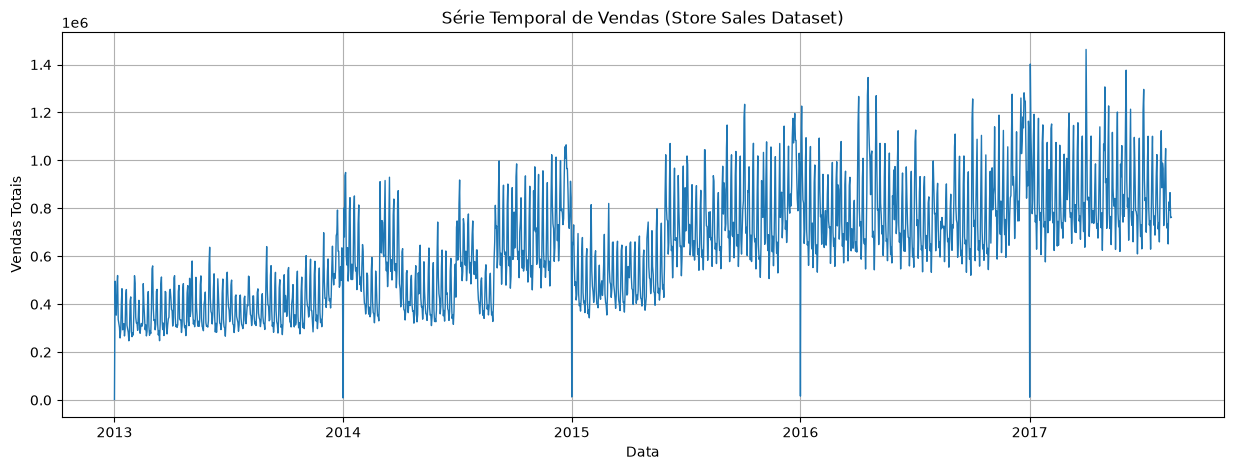

In [18]:
plt.figure(figsize=(15,5))
plt.plot(sales, linewidth=1)
plt.title("Série Temporal de Vendas (Store Sales Dataset)")
plt.xlabel("Data")
plt.ylabel("Vendas Totais")
plt.grid(True)
plt.show()

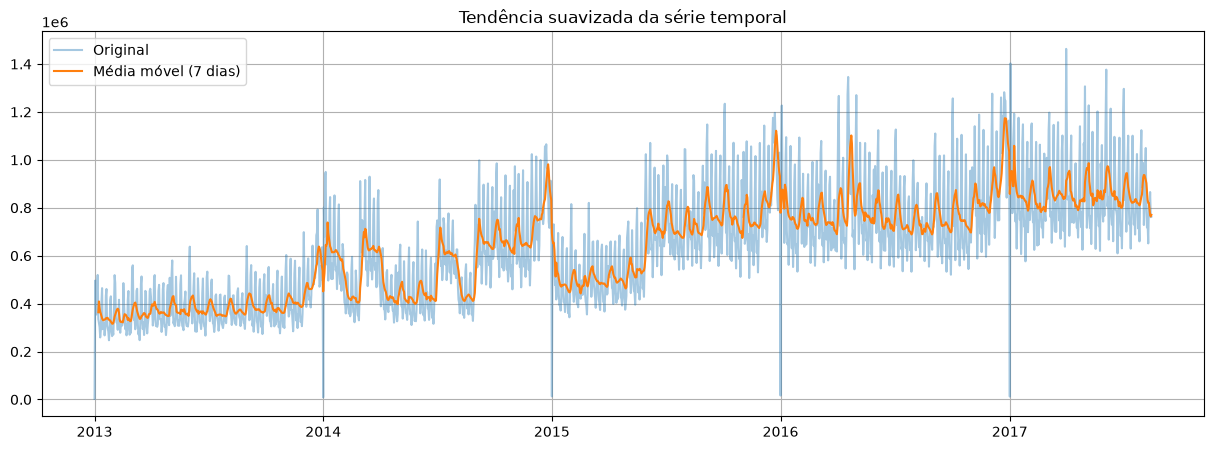

In [19]:
sales_ma7 = sales.rolling(window=7).mean()

plt.figure(figsize=(15,5))
plt.plot(sales, alpha=0.4, label="Original")
plt.plot(sales_ma7, label="Média móvel (7 dias)")
plt.legend()
plt.title("Tendência suavizada da série temporal")
plt.grid(True)
plt.show()

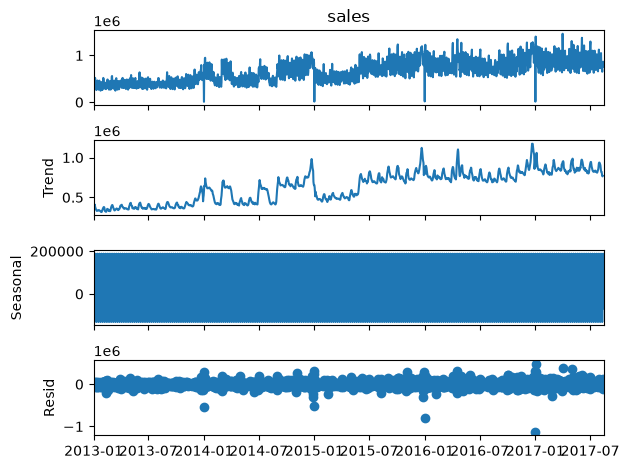

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(sales, model='additive', period=7)

result.plot()
plt.show()

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

<Figure size 1200x500 with 0 Axes>

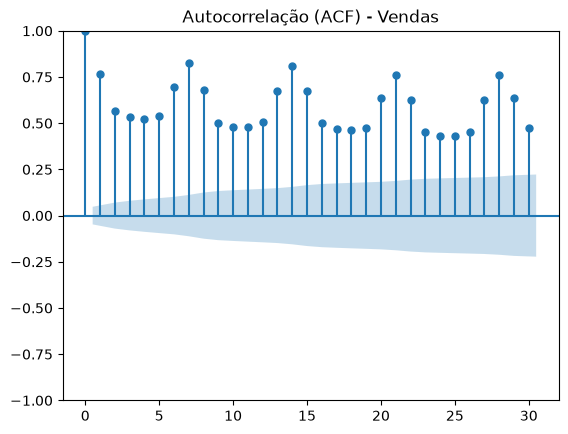

In [25]:
plt.figure(figsize=(12,5))
plot_acf(sales, lags=30)
plt.title("Autocorrelação (ACF) - Vendas")
plt.show()

<Figure size 1200x500 with 0 Axes>

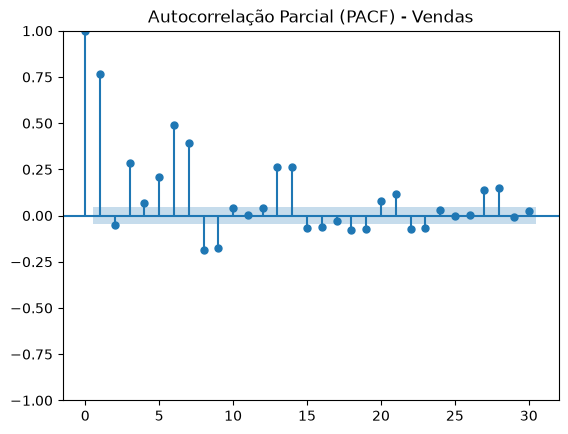

In [26]:
plt.figure(figsize=(12,5))
plot_pacf(sales, lags=30)
plt.title("Autocorrelação Parcial (PACF) - Vendas")
plt.show()

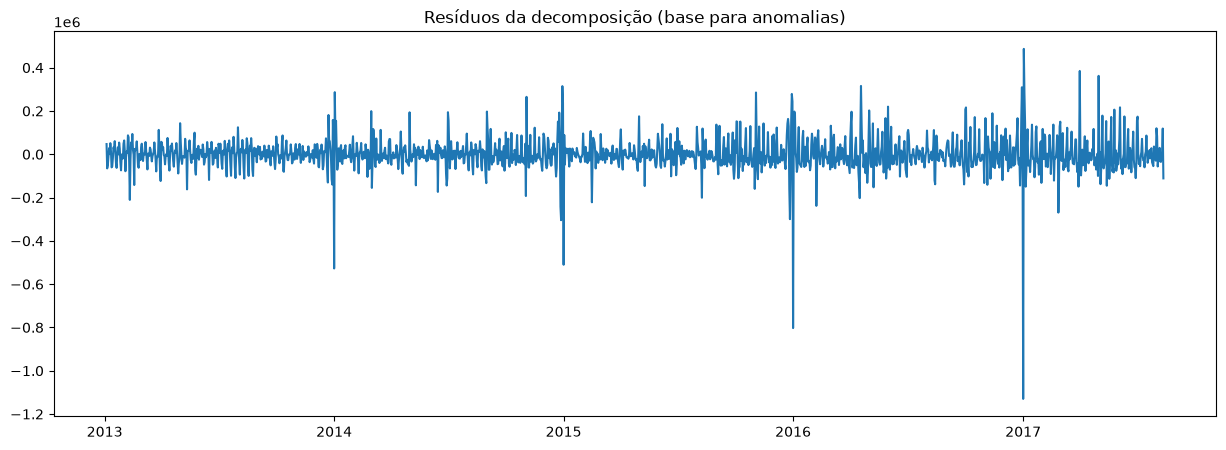

In [27]:
residual = result.resid

plt.figure(figsize=(15,5))
plt.plot(residual)
plt.title("Resíduos da decomposição (base para anomalias)")
plt.show()

In [28]:
residual_mean = residual.mean()
residual_std = residual.std()

upper_limit = residual_mean + 2 * residual_std
lower_limit = residual_mean - 2 * residual_std

In [29]:
anomalies = residual[(residual > upper_limit) | (residual < lower_limit)]

anomalies.head()

date
2013-02-10   -210743.614694
2013-05-12   -162053.621727
2013-12-23    181405.168184
2013-12-30    158388.340788
2014-01-01   -527498.985237
Name: resid, dtype: float64

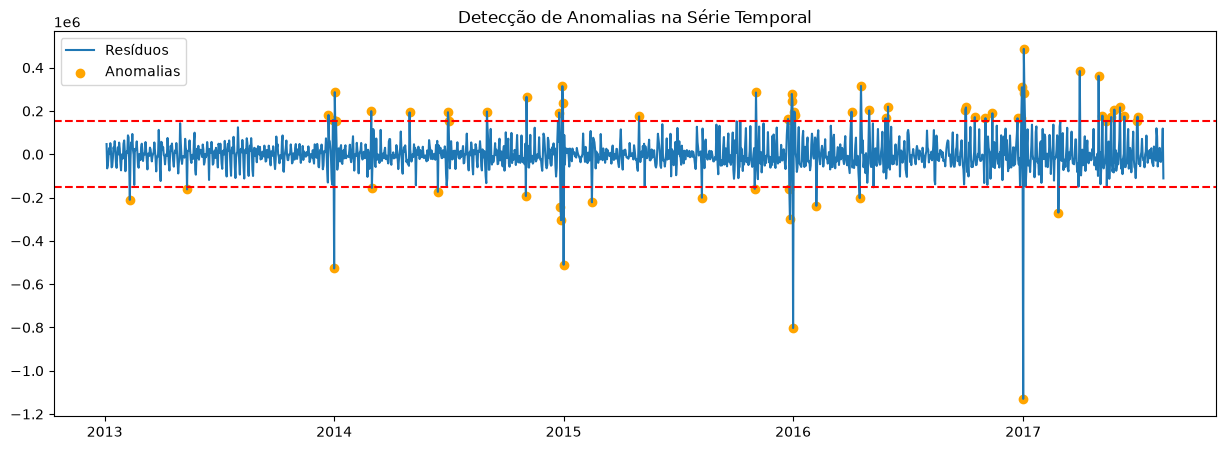

In [30]:
plt.figure(figsize=(15,5))
plt.plot(residual, label="Resíduos")
plt.axhline(upper_limit, color="red", linestyle="--")
plt.axhline(lower_limit, color="red", linestyle="--")
plt.scatter(anomalies.index, anomalies, color="orange", label="Anomalias")
plt.legend()
plt.title("Detecção de Anomalias na Série Temporal")
plt.show()

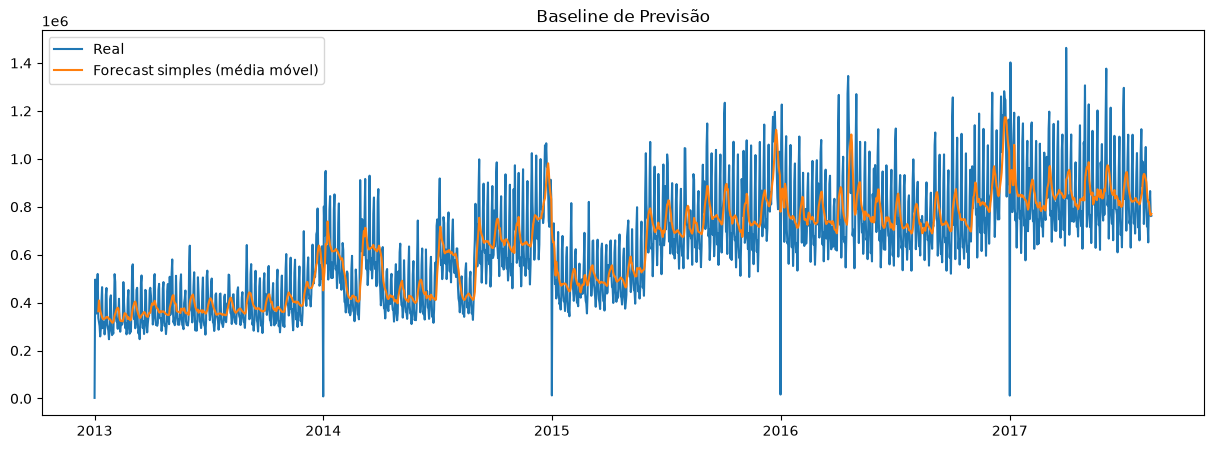

In [31]:
forecast = sales.rolling(window=7).mean()

plt.figure(figsize=(15,5))
plt.plot(sales, label="Real")
plt.plot(forecast, label="Forecast simples (média móvel)")
plt.legend()
plt.title("Baseline de Previsão")
plt.show()

In [32]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [33]:
model = ExponentialSmoothing(
    sales,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_fit = model.fit()
forecast_hw = hw_fit.fittedvalues

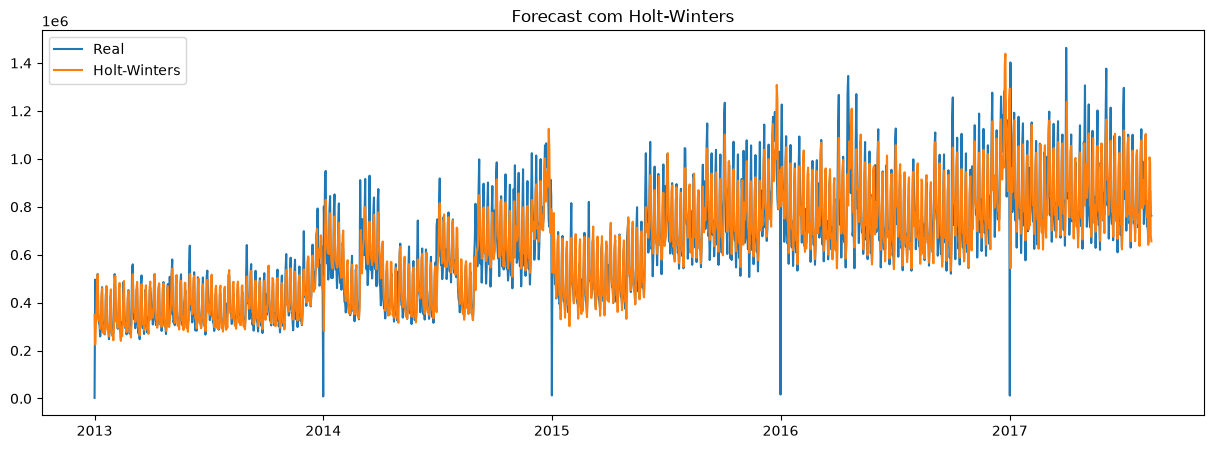

In [34]:
plt.figure(figsize=(15,5))
plt.plot(sales, label="Real")
plt.plot(forecast_hw, label="Holt-Winters")
plt.legend()
plt.title("Forecast com Holt-Winters")
plt.show()